# Climate and Energy Transition Lab Template

Python code template for the Climate and Energy Transition lab on May 6, 2026.

This document provides:

- a list of Python modules to import
- a model for importing `.csv` data tables formatted with French conventions
- parameters for writing time labels on a figure axis with monthly ticks
- a plotting template for time-indexed data, with titles, labels, and an export command.

@author: Martin Hennebel

In [1]:
# useful modules to import
import math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates
import locale # for local date settings

locale.setlocale(locale.LC_ALL, 'fr_FR.utf8') # use French date formatting

'fr_FR.utf8'

## Links to useful pandas function documentation

10 minutes to pandas  
https://pandas.pydata.org/docs/user_guide/10min.html

A tutorial to get started with time series in pandas:  
https://pandas.pydata.org/docs/getting_started/intro_tutorials/09_timeseries.html

User guide for handling time series with pandas  
https://pandas.pydata.org/docs/user_guide/timeseries.html

Reference documentation for pandas functions used to process `DataFrame` data tables  
https://pandas.pydata.org/docs/reference/frame.html

Among these functions, some useful ones to look at are:

Indexing:

- `pandas.DataFrame.index()` to retrieve the row index
- `pandas.DataFrame.columns()` to retrieve the column names
- `pandas.DataFrame.dtypes()` to retrieve the data types in the table
- `pandas.DataFrame.loc()` to extract data selected by labels
- `pandas.DataFrame.iloc()` to extract data selected by integer positions

Value processing:

- `pandas.DataFrame.max()` to get the maximum (`min` for the minimum)
- `pandas.DataFrame.idxmax()` to get the index of the maximum (`min` for the minimum)
- `pandas.DataFrame.nlargest()` to get the n largest values (`nsmallest` for the smallest)
- `pandas.DataFrame.sum(numeric_only=True)` to sum column contents, numeric values only
- `pandas.DataFrame.mean()` to average column contents
- `pandas.DataFrame.to_timestamp()` to transform indexes into a time format
- `pandas.DataFrame.tz_convert()` to convert a time index from one time zone to another (Continental European Time for Paris)
- `pandas.DataFrame.tz_localize()` to assign a time zone to a naive time index
- `pandas.to_datetime` to convert arguments into date + time (`datetime`)
- `pandas.DataFrame.sort_values` to sort values

## Data Import Template

Import data from a CSV file formatted with French conventions (`;` as the separator, comma as the decimal separator, date parsing enabled).

In [2]:
france_2024_data = pd.read_csv(
    'edunao-files/Donnees_France_2024_fr_cet.csv',
    sep=';',
    decimal=',',
    index_col=[0],
    parse_dates=[0],
    date_format="ISO8601",
)

## Time Label Parameters

Time-label parameters for the time axis in figures.

In [3]:
# monthly interval for labels
Month = mdates.MonthLocator(bymonthday=1) # every month, on the first day of the month.

# month display format
MonthFmt = mdates.DateFormatter('%b') # abbreviated month name.
# Hours = mdates.HourLocator()

## Figure Plotting Template

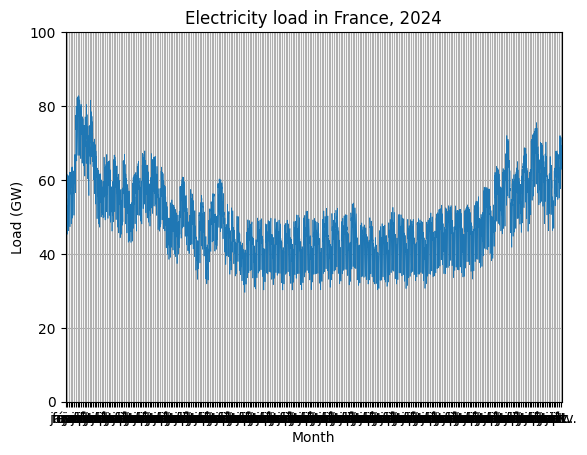

<Figure size 640x480 with 0 Axes>

In [4]:
# Create the axes
fig, ax = plt.subplots()

# plot the load curve against time, with values divided by 1000 to convert MW to GW.
ax.plot(france_2024_data.index, (france_2024_data['Load'].values / 1000), linewidth=.5)

# display the title
plt.title('Electricity load in France, 2024')

# min and max limits of the x-axis
ax.set_xlim(france_2024_data.index[0], france_2024_data.index[-1])

# place time labels at each month
ax.xaxis.set_major_locator(Month)

# format time labels
ax.xaxis.set_major_formatter(MonthFmt)

# x-axis label
plt.xlabel('Month')

# min and max limits of the y-axis
ax.set_ylim(0, 100)

# y-axis label
plt.ylabel('Load (GW)')

# display the grid to make values easier to read
plt.grid(True)

# display the figure
plt.show()

# save the figure as .svg:
plt.savefig(r'path\to\directory\File_Name.svg')

# figure exports should use vector formats: .svg, .emf, .eps
# Avoid raster formats, which are heavy and become blurry when enlarged: .bmp, .jpg ...